<a href="https://colab.research.google.com/github/jaya200591/AICTE1/blob/main/online_payments_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import os
for dirname, _, filenames in os.walk('data.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [7]:
df=pd.read_csv('data.csv.csv')

In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3546654 entries, 0 to 3546653
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 297.6+ MB


In [10]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3546649,260,PAYMENT,7829.76,C28616592,22116.00,14286.24,M1321576916,0.0,0.0,0.0,0.0
3546650,260,PAYMENT,10792.26,C697109667,14286.24,3493.98,M1786562305,0.0,0.0,0.0,0.0
3546651,260,PAYMENT,6796.17,C1313895929,824941.00,818144.83,M758709998,0.0,0.0,0.0,0.0
3546652,260,CASH_IN,131307.53,C1821448190,11383.00,142690.53,C1998046670,0.0,0.0,0.0,0.0
3546653,260,PAYMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.shape

(3546654, 11)

In [12]:
df['type'].value_counts()

,count
type,
CASH_OUT,1265140
PAYMENT,1188985
CASH_IN,777607
TRANSFER,293097
DEBIT,21825


In [13]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0.0,3546651
1.0,2


In [14]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,3543734
1.0,2919


In [15]:
df[(df['type']=='TRANSFER') | (df['type']=='PAYEMENT')]['isFraud'].value_counts()

,count
isFraud,
0.0,291647
1.0,1450


In [16]:
df=df.drop('isFlaggedFraud',axis=1)

In [17]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,3543734
1.0,2919


In [18]:
df = df[df['type'].isin(['TRANSFER', 'PAYMENT'])]

In [19]:
df.shape

(1482082, 10)

In [20]:
df[df.duplicated()]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud


In [21]:
df.isnull().sum()

,0
step,0
type,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [22]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.0,1.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.0,0.0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
3546648,260,PAYMENT,3917.30,C1882387388,21012.00,17094.70,M1326548079,0.0,0.0,0.0
3546649,260,PAYMENT,7829.76,C28616592,22116.00,14286.24,M1321576916,0.0,0.0,0.0
3546650,260,PAYMENT,10792.26,C697109667,14286.24,3493.98,M1786562305,0.0,0.0,0.0
3546651,260,PAYMENT,6796.17,C1313895929,824941.00,818144.83,M758709998,0.0,0.0,0.0


In [24]:

df['hour'] = df['step'] % 24  # Extract hour from step (since 1 step = 1 hour)
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)

In [25]:
df['hour'] = df['step'] % 24  # Extract hour from step (since 1 step = 1 hour)
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)  # Flag night transactions

In [26]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,1,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,1,1
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0.0,1,1


In [27]:
df['amount_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # Avoid division by zero


In [28]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,1,1,0.057834
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,1,1,0.087731
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,1,1,0.994505
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,1,1,0.280788
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0.0,1,1,0.145146


In [29]:
df['sender_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['receiver_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

In [30]:
df[df['isFraud']==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.0,1.0,1,1,0.994505,181.00,0.0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.0,0.0,1.0,1,1,0.999644,2806.00,0.0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.0,0.0,1.0,1,1,0.999950,20128.00,0.0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.00,C431687661,0.0,0.0,1.0,1,1,0.999999,1277212.77,0.0
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.00,C1136419747,0.0,0.0,1.0,1,1,0.999971,35063.63,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3530903,259,TRANSFER,248071.56,C1429503291,248071.56,0.00,C1044014885,0.0,0.0,1.0,19,0,0.999996,248071.56,0.0
3535937,259,TRANSFER,8274020.94,C840630111,8274020.94,0.00,C825235440,0.0,0.0,1.0,19,0,1.000000,8274020.94,0.0
3540100,260,TRANSFER,60226.06,C415054779,60226.06,0.00,C20386359,0.0,0.0,1.0,20,0,0.999983,60226.06,0.0
3542877,260,TRANSFER,10000000.00,C1799904347,10175597.64,175597.64,C1817199105,0.0,0.0,1.0,20,0,0.982743,10000000.00,0.0


In [31]:
df['orig_balance_zero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['dest_balance_zero'] = (df['oldbalanceDest'] == 0).astype(int)

In [32]:
df.sample(4)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero
2626351,209,PAYMENT,10696.13,C1169951766,342403.15,331707.02,M2025563032,0.00,0.00,0.0,17,0,0.031238,10696.13,0.00,0,1
1280092,135,PAYMENT,33006.84,C1598347939,1369996.55,1336989.71,M1590740160,0.00,0.00,0.0,15,0,0.024093,33006.84,0.00,0,1
1274108,135,TRANSFER,3495.45,C706494489,0.00,0.00,C749013731,17751697.37,17755192.82,0.0,15,0,3495.450000,0.00,3495.45,1,0
2765683,213,PAYMENT,1587.89,C117102191,0.00,0.00,M889945610,0.00,0.00,0.0,21,0,1587.890000,0.00,0.00,1,1


In [33]:
df[df['isFraud']==1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.0,1.0,1,1,0.994505,181.00,0.0,0,1
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.0,0.0,1.0,1,1,0.999644,2806.00,0.0,0,1
680,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.0,0.0,1.0,1,1,0.999950,20128.00,0.0,0,1
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.00,C431687661,0.0,0.0,1.0,1,1,0.999999,1277212.77,0.0,0,1
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.00,C1136419747,0.0,0.0,1.0,1,1,0.999971,35063.63,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3530903,259,TRANSFER,248071.56,C1429503291,248071.56,0.00,C1044014885,0.0,0.0,1.0,19,0,0.999996,248071.56,0.0,0,1
3535937,259,TRANSFER,8274020.94,C840630111,8274020.94,0.00,C825235440,0.0,0.0,1.0,19,0,1.000000,8274020.94,0.0,0,1
3540100,260,TRANSFER,60226.06,C415054779,60226.06,0.00,C20386359,0.0,0.0,1.0,20,0,0.999983,60226.06,0.0,0,1
3542877,260,TRANSFER,10000000.00,C1799904347,10175597.64,175597.64,C1817199105,0.0,0.0,1.0,20,0,0.982743,10000000.00,0.0,0,1


In [34]:
dummies=pd.get_dummies(df['type']).astype(int)
dummies.tail()

,PAYMENT,TRANSFER
3546648,1,0
3546649,1,0
3546650,1,0
3546651,1,0
3546653,1,0


In [35]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [36]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,1,1,0.057834,9839.64,0.0,0,1,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,1,1,0.087731,1864.28,0.0,0,1,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,1,1,0.994505,181.00,0.0,0,1,True
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,1,1,0.280788,11668.14,0.0,0,1,False
5,1,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0.0,1,1,0.145146,7817.71,0.0,0,1,False


In [37]:
df['type_TRANSFER'] = df['type_TRANSFER'].astype(int)
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,1,1,0.057834,9839.64,0.0,0,1,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,1,1,0.087731,1864.28,0.0,0,1,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,1,1,0.994505,181.00,0.0,0,1,1
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,1,1,0.280788,11668.14,0.0,0,1,0
5,1,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0.0,1,1,0.145146,7817.71,0.0,0,1,0


In [38]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [39]:
df.shape

(1482082, 15)

In [40]:
df.sample(10)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_TRANSFER
1609575,156,2076922.66,20843.00,0.00,21249946.26,23326868.93,0.0,12,0,99.641271,20843.00,2076922.67,0,0,1
1645883,157,1022857.12,739.00,0.00,1661322.09,2684179.22,0.0,13,0,1382.239351,739.00,1022857.13,0,0,1
895026,42,3529.55,302152.00,298622.45,0.00,0.00,0.0,18,0,0.011681,3529.55,0.00,0,1,0
3490026,258,8242.41,0.00,0.00,0.00,0.00,0.0,18,0,8242.410000,0.00,0.00,1,1,0
2524340,205,7519.11,187421.54,179902.43,0.00,0.00,0.0,13,0,0.040118,7519.11,0.00,0,1,0
212994,13,546.40,0.00,0.00,0.00,0.00,0.0,13,0,546.400000,0.00,0.00,1,1,0
3179193,239,5740.91,61774.00,56033.09,0.00,0.00,0.0,23,0,0.092933,5740.91,0.00,0,1,0
582053,33,5636.80,0.00,0.00,0.00,0.00,0.0,9,0,5636.800000,0.00,0.00,1,1,0
799379,40,22259.04,191386.98,169127.94,0.00,0.00,0.0,16,0,0.116303,22259.04,0.00,0,1,0
1894354,165,12347.77,5483.17,0.00,0.00,0.00,0.0,21,0,2.251529,5483.17,0.00,0,1,0


<Axes: >

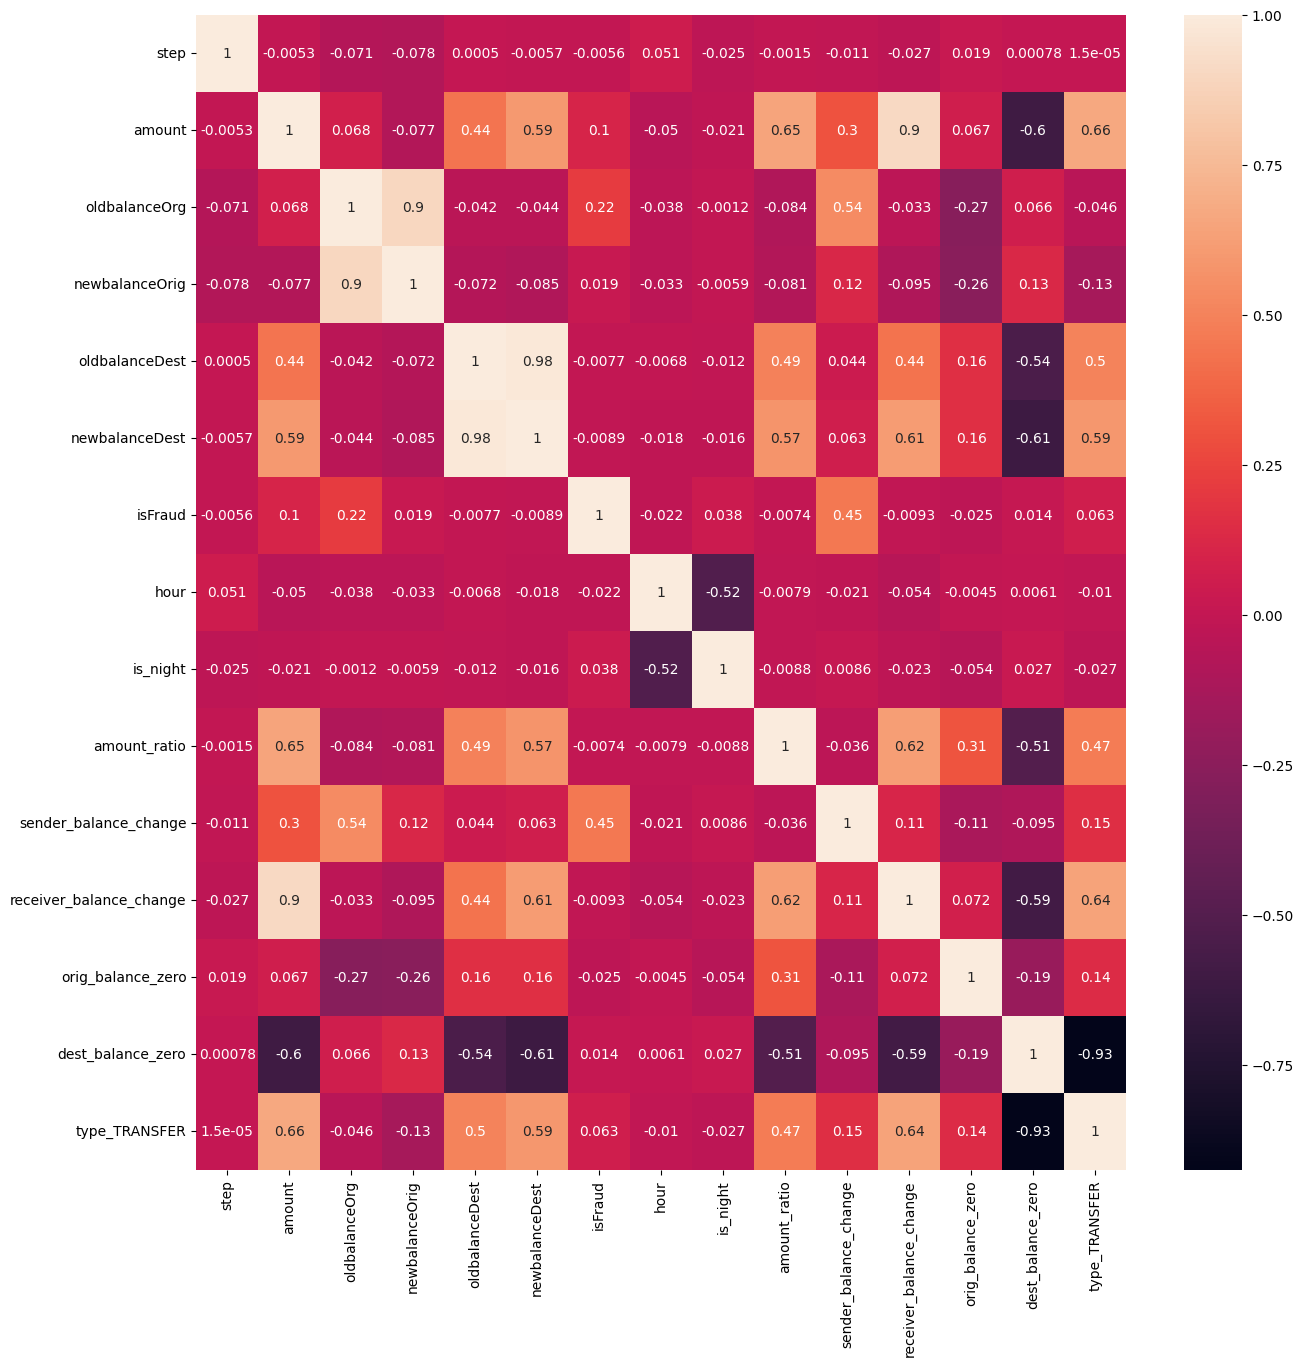

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
corr=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr ,annot=True)

In [42]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_TRANSFER
count,1.482082e+06,1.482081e+06,1.482081e+06,1.482081e+06,1.482081e+06,1.482081e+06,1.482081e+06,1.482082e+06,1.482082e+06,1.482081e+06,1.482081e+06,1.482081e+06,1.482082e+06,1.482082e+06,1.482082e+06
mean,1.430891e+02,1.344144e+05,6.965138e+04,5.663131e+04,3.956358e+05,5.266507e+05,9.783541e-04,1.508936e+01,2.672524e-02,6.462995e+04,1.302007e+04,1.310148e+05,3.896039e-01,8.257020e-01,1.977603e-01
std,8.321726e+01,3.714966e+05,2.066834e+05,1.753196e+05,1.589010e+06,1.806888e+06,3.126336e-02,4.650546e+00,1.612793e-01,2.582035e+05,9.111360e+04,4.117767e+05,4.876606e-01,3.793657e-01,3.983105e-01
min,1.000000e+00,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.462010e-07,0.000000e+00,-6.755514e+06,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.200000e+01,5.145710e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.200000e+01,0.000000e+00,1.762013e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,1.620000e+02,1.169406e+04,8.045000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,5.619583e+00,1.728010e+03,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2.100000e+02,2.935537e+04,5.601600e+04,3.529828e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01,0.000000e+00,8.432080e+03,1.031705e+04,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,2.600000e+02,1.000000e+07,3.767004e+07,2.767004e+07,4.138365e+07,4.205466e+07,1.000000e+00,2.300000e+01,1.000000e+00,9.089850e+06,1.000000e+07,3.889205e+07,1.000000e+00,1.000000e+00,1.000000e+00


In [43]:
X=df.drop('isFraud',axis=1)
y=df['isFraud']

In [44]:
X

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hour,is_night,amount_ratio,sender_balance_change,receiver_balance_change,orig_balance_zero,dest_balance_zero,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.0,0.0,1,1,0.057834,9839.64,0.0,0,1,0
1,1,1864.28,21249.00,19384.72,0.0,0.0,1,1,0.087731,1864.28,0.0,0,1,0
2,1,181.00,181.00,0.00,0.0,0.0,1,1,0.994505,181.00,0.0,0,1,1
4,1,11668.14,41554.00,29885.86,0.0,0.0,1,1,0.280788,11668.14,0.0,0,1,0
5,1,7817.71,53860.00,46042.29,0.0,0.0,1,1,0.145146,7817.71,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3546648,260,3917.30,21012.00,17094.70,0.0,0.0,20,0,0.186423,3917.30,0.0,0,1,0
3546649,260,7829.76,22116.00,14286.24,0.0,0.0,20,0,0.354015,7829.76,0.0,0,1,0
3546650,260,10792.26,14286.24,3493.98,0.0,0.0,20,0,0.755378,10792.26,0.0,0,1,0
3546651,260,6796.17,824941.00,818144.83,0.0,0.0,20,0,0.008238,6796.17,0.0,0,1,0


In [45]:
y

,isFraud
0,0.0
1,0.0
2,1.0
4,0.0
5,0.0
...,...
3546648,0.0
3546649,0.0
3546650,0.0
3546651,0.0


In [46]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,shuffle=True)

In [47]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1111561, 14), (370521, 14), (1111561,), (370521,))

In [48]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [49]:
X_train_scaled

array([[ 1.27313084, -0.34212863, -0.3402694 , ...,  1.25114656,
         0.45966309, -0.496666  ],
       [ 0.73259331, -0.29651993, -0.33948045, ..., -0.79926688,
         0.45966309, -0.496666  ],
       [ 1.06892778, -0.27761843,  0.74071663, ..., -0.79926688,
         0.45966309, -0.496666  ],
       ...,
       [-1.52565239, -0.22740256,  0.34360272, ..., -0.79926688,
         0.45966309, -0.496666  ],
       [ 0.15601994,  4.41599992, -0.26367354, ..., -0.79926688,
        -2.17550643,  2.01342554],
       [-1.53766434, -0.34188303, -0.3402694 , ...,  1.25114656,
         0.45966309, -0.496666  ]])

In [50]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=10000)

In [55]:
import pandas as pd

df = pd.read_csv("data.csv.csv")

print(df.isnull().sum())
print(df.isnull().sum().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
0


In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])
df['nameOrig'] = le.fit_transform(df['nameOrig'])
df['nameDest'] = le.fit_transform(df['nameDest'])

In [57]:
from sklearn.model_selection import train_test_split

X = df.drop("isFraud", axis=1)
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
import numpy as np

print(np.isnan(X_train_scaled).sum())

0


In [61]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [63]:
# Predict the test data
y_pred = lr.predict(X_test_scaled)

In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc_score:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9992

Confusion Matrix:
[[1270835      69]
 [    962     658]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.91      0.41      0.56      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.70      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



In [65]:
from sklearn.tree import DecisionTreeClassifier

In [66]:
dt=DecisionTreeClassifier(max_depth=5,class_weight={0: 1, 1: 10})

In [67]:
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 10}, max_depth=5)

[Text(0.5089285714285714, 0.9166666666666666, 'x[2] <= 2044828.312\ngini = 0.025\nsamples = 5090096\nvalue = [5083503, 65930]'),
 Text(0.32142857142857145, 0.75, 'x[0] <= 718.5\ngini = 0.02\nsamples = 5055739\nvalue = [5050492, 52470]'),
 Text(0.4151785714285714, 0.8333333333333333, 'True  '),
 Text(0.2857142857142857, 0.5833333333333334, 'x[1] <= 3.5\ngini = 0.02\nsamples = 5055550\nvalue = [5050492.0, 50580.0]'),
 Text(0.14285714285714285, 0.4166666666666667, 'x[2] <= 871485.25\ngini = 0.011\nsamples = 4662881\nvalue = [4660337, 25440]'),
 Text(0.07142857142857142, 0.25, 'x[2] <= 696568.125\ngini = 0.009\nsamples = 4661592\nvalue = [4659551.0, 20410.0]'),
 Text(0.03571428571428571, 0.08333333333333333, 'gini = 0.008\nsamples = 4656686\nvalue = [4654785, 19010]'),
 Text(0.10714285714285714, 0.08333333333333333, 'gini = 0.351\nsamples = 4906\nvalue = [4766, 1400]'),
 Text(0.21428571428571427, 0.25, 'x[4] <= 863832.0\ngini = 0.234\nsamples = 1289\nvalue = [786, 5030]'),
 Text(0.17857142

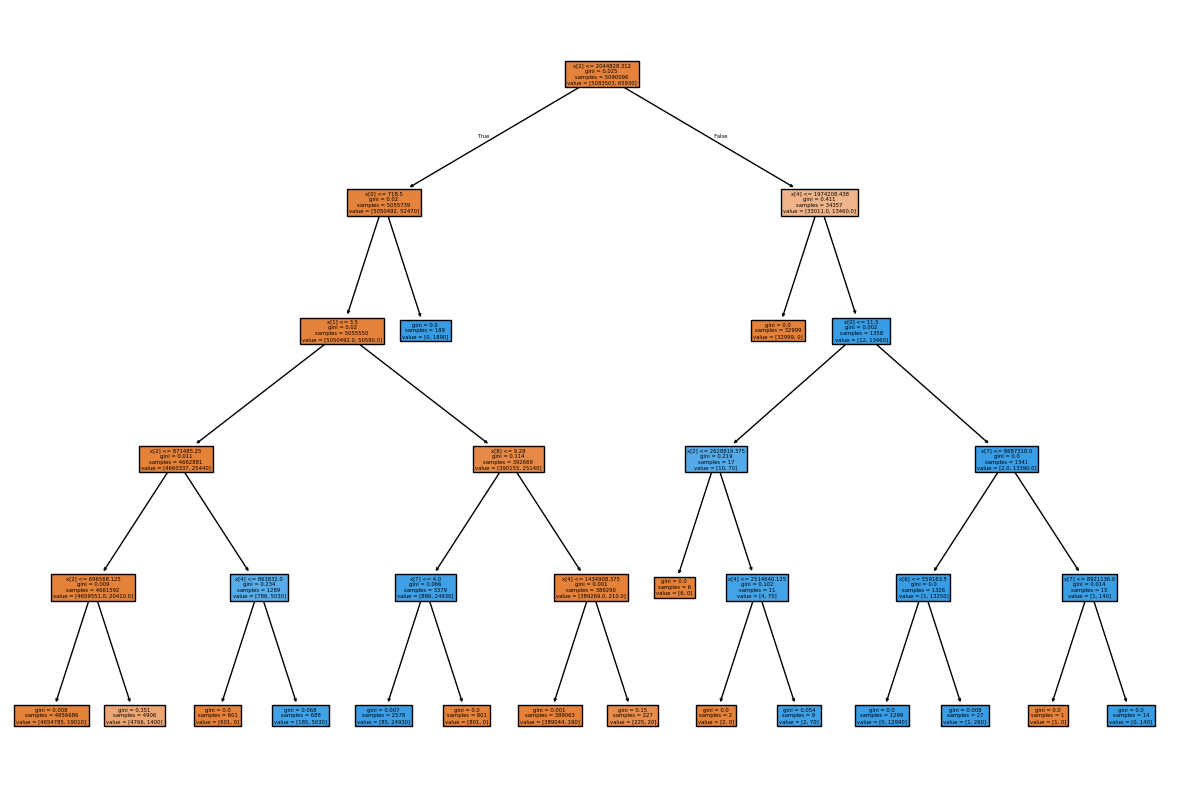

In [68]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dt,filled=True)

In [69]:
dt.get_depth()

5

In [70]:
y_pred=dt.predict(X_test)

In [71]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [72]:
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report

In [73]:
acc_score=accuracy_score(y_test,y_pred)
print(f"accuracy score :{acc_score} ")
print()
print("Confusion matrix :")
print(confusion_matrix(y_test,y_pred))
print()
print("Classification Report :")
print(classification_report(y_test,y_pred))

accuracy score :0.9995481421175554 

Confusion matrix :
[[1270837      67]
 [    508    1112]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.94      0.69      0.79      1620

    accuracy                           1.00   1272524
   macro avg       0.97      0.84      0.90   1272524
weighted avg       1.00      1.00      1.00   1272524

